# 01 · Ingesta, normalización y segmentación

Procesar el corpus completo de HTML y PDF, segmentarlo y conservar la procedencia de cada fragmento.

La normalización mantiene tildes, cifras, referencias y tachados explícitos del HTML. Las notas editoriales y la vigencia declarada se conservan para revisión.



## 1. Datos y selección

In [18]:
import hashlib
import io
import json
import re
import unicodedata
from importlib.metadata import version
from pathlib import Path

import pandas as pd
from bs4 import BeautifulSoup, Comment, NavigableString, Tag, UnicodeDammit
from ftfy import fix_encoding
from IPython.display import display
import pdfplumber

MODO = "corpus"  # "muestra" o "corpus"
IDS_MUESTRA = ["ley_1581_2012", "ley_1032_2006"]
VERSION_INGESTA = "0.2.0"
MAX_CARACTERES = 1800
SOLAPAMIENTO = 200

RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/raw/manifest.json").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("No se encontró data/raw/manifest.json desde esta carpeta.")
RAW = RAIZ / "data" / "raw"
manifest_bytes = (RAW / "manifest.json").read_bytes()
manifest = json.loads(manifest_bytes.decode("utf-8"))
if MODO not in {"muestra", "corpus"}:
    raise ValueError("MODO debe ser muestra o corpus.")
DESTINO = RAIZ / "data" / "processed" / MODO
ids = [d["doc_id"] for d in manifest]
if not ids or len(ids) != len(set(ids)) or any(not re.fullmatch(r"[A-Za-z0-9_-]+", i) for i in ids):
    raise ValueError("El manifiesto está vacío o contiene doc_id repetidos o no válidos.")
if MODO == "muestra" and (not IDS_MUESTRA or set(IDS_MUESTRA) - set(ids)):
    raise ValueError("La muestra está vacía o contiene doc_id ausentes del manifiesto.")
seleccion = sorted([d for d in manifest if MODO == "corpus" or d["doc_id"] in IDS_MUESTRA],
                   key=lambda d: d["doc_id"])
print(f"Modo: {MODO}. Documentos: {len(seleccion)}. Salida: data/processed/{MODO}/")

Modo: corpus. Documentos: 282. Salida: data/processed/corpus/


## 2. Normalización

Se corrige la codificación y se ordenan los espacios. Se mantienen mayúsculas, puntuación y saltos entre bloques.

In [19]:
def sha256(contenido):
    return hashlib.sha256(contenido).hexdigest()


def normalizar(texto):
    texto = unicodedata.normalize("NFC", fix_encoding(texto))
    texto = texto.replace("\r\n", "\n").replace("\r", "\n")
    texto = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\u200b\ufeff]", "", texto)
    lineas = [re.sub(r"[^\S\n]+", " ", linea).strip() for linea in texto.split("\n")]
    return "\n".join(linea for linea in lineas if linea)


def leer_original(archivo):
    ruta = (RAW / archivo["archivo"]).resolve()
    if not ruta.is_relative_to(RAW.resolve()):
        raise ValueError("La ruta sale de data/raw.")
    contenido = ruta.read_bytes()
    if len(contenido) != archivo["bytes"] or sha256(contenido) != archivo["sha256"]:
        raise ValueError(f"El original no coincide con el manifiesto: {archivo['archivo']}")
    return contenido

## 3. Extracción de HTML

Se toma el cuerpo del documento y se retiran scripts y controles de navegación. Las notas de la edición se señalan para revisión antes de indexar o publicar.

In [20]:
def extraer_html(contenido, archivo):
    html, encoding = None, None
    for candidato in ["utf-8-sig", archivo.get("encoding")]:
        if not candidato:
            continue
        try:
            html, encoding = contenido.decode(candidato), candidato
            break
        except (UnicodeDecodeError, LookupError):
            pass
    if html is None:
        detectado = UnicodeDammit(contenido, is_html=True)
        html, encoding = detectado.unicode_markup, detectado.original_encoding
    if html is None:
        raise ValueError("No fue posible decodificar el HTML.")
    soup = BeautifulSoup(html, "html.parser")
    principal, selector = soup.body or soup, "body"
    for candidato in ["#aj_data", ".descripcion-contenido", ".panel-documento",
                      "#documento", "#contenidoNorma", "article"]:
        elementos = soup.select(candidato)
        if elementos and len(elementos[-1].get_text()) > 200:
            principal, selector = elementos[-1], candidato
            break
    editorial = bool(soup.select("#aj_data, .panel-documento"))
    for etiqueta in list(principal.select("script, style, noscript, nav, header, footer, form, button, iframe")):
        if etiqueta.parent is not None:
            etiqueta.decompose()
    bloques = {"p", "div", "section", "h1", "h2", "h3", "h4", "h5", "h6", "li", "tr", "table", "br"}
    partes = []

    def recorrer(nodo):
        if isinstance(nodo, Comment):
            return
        if isinstance(nodo, NavigableString):
            partes.append(str(nodo))
        elif isinstance(nodo, Tag):
            tachado = nodo.name in {"s", "strike", "del"} or "line-through" in nodo.get("style", "").lower()
            if nodo.name in bloques:
                partes.append("\n")
            if tachado:
                partes.append(" [TEXTO TACHADO EN LA FUENTE: ")
            for hijo in nodo.children:
                recorrer(hijo)
            if tachado:
                partes.append("] ")
            if nodo.name in {"td", "th"}:
                partes.append(" | ")
            if nodo.name in bloques:
                partes.append("\n")

    recorrer(principal)
    texto = normalizar("".join(partes))
    if len(texto) < 1500 and re.search(r"captcha|access denied|just a moment|acceso denegado|page not found", texto, re.I):
        raise ValueError("El HTML contiene una página de bloqueo o error.")
    return [{"pagina": None, "texto": texto}], {
        "selector": selector, "encoding": encoding, "anotaciones_detectadas": editorial,
        "paginas_pdf": None, "paginas_con_poco_texto": [],
    }

## 4. Extracción de PDF

Se conserva el número de página. Los PDF quedan señalados para revisar el orden de lectura y los posibles errores de extracción. Tener texto no garantiza que se haya leído bien. No se realiza OCR en este paso.

La extracción sigue el flujo de texto del PDF. También se registra si el original carece del marcador de cierre completo.

In [21]:
def extraer_pdf(contenido):
    inicio = contenido[:1024].find(b"%PDF-")
    if inicio < 0:
        raise ValueError("El archivo no tiene cabecera PDF.")
    with pdfplumber.open(io.BytesIO(contenido[inicio:])) as lector:
        paginas = [{"pagina": i, "texto": normalizar(pagina.extract_text(use_text_flow=True) or "")}
                   for i, pagina in enumerate(lector.pages, start=1)]
    poco_texto = [p["pagina"] for p in paginas if len(p["texto"].strip()) < 40]
    return paginas, {
        "selector": "pdfplumber_text_flow", "encoding": "PDF", "anotaciones_detectadas": False,
        "paginas_pdf": len(paginas), "paginas_con_poco_texto": poco_texto,
        "offset_cabecera_pdf": inicio, "cierre_pdf_completo": contenido.rstrip().endswith(b"%%EOF"),
    }

## 5. Procesamiento

Cada texto conserva su archivo original, URL y página. `revisar` señala limitaciones de extracción o anotaciones. La vigencia permanece como consta en el manifiesto. La revisión jurídica sigue pendiente.

In [12]:
def procesar_documento(documento):
    texto, partes, extraccion, avisos = "", [], [], []
    if not documento.get("archivos_raw"):
        raise ValueError("El documento no tiene originales.")
    for archivo in documento["archivos_raw"]:
        contenido = leer_original(archivo)
        extension = Path(archivo["archivo"]).suffix.lower()
        if extension in {".html", ".htm"}:
            bloques, info = extraer_html(contenido, archivo)
        elif extension == ".pdf":
            bloques, info = extraer_pdf(contenido)
            avisos.append("revisar_orden_y_texto_pdf")
        else:
            raise ValueError(f"Formato no admitido: {extension}")
        extraccion.append({"archivo": archivo["archivo"], **info})
        if info.get("cierre_pdf_completo") is False:
            avisos.append("original_pdf_sin_cierre_completo")
        if info["anotaciones_detectadas"]:
            avisos.append("anotaciones_editoriales")
        if info["paginas_con_poco_texto"]:
            avisos.append("paginas_con_poco_texto_revisar_OCR")
        for bloque in bloques:
            if texto:
                texto += "\n\n"
            cabecera = f"[PÁGINA {bloque['pagina']}]\n" if bloque["pagina"] is not None else ""
            texto += cabecera
            inicio = len(texto)
            texto += bloque["texto"]
            partes.append({"archivo": archivo["archivo"], "url": archivo.get("url_final") or archivo["url"],
                           "pagina": bloque["pagina"], "inicio": inicio, "fin": len(texto)})
    caracteres_extraidos = sum(p["fin"] - p["inicio"] for p in partes)
    if caracteres_extraidos == 0:
        raise ValueError("No se extrajo texto; revisar original u OCR.")
    if caracteres_extraidos < 200:
        avisos.append("texto_corto")
    if "\ufffd" in texto:
        avisos.append("caracteres_de_reemplazo")
    if documento.get("edicion_con_anotaciones") or documento.get("redistribuir_raw") is not True:
        avisos.append("revisar_anotaciones_y_publicacion")
    avisos = sorted(set(avisos))
    registro = {**documento, "version_ingesta": VERSION_INGESTA,
                "estado_extraccion": "revisar" if avisos else "extraido",
                "revision_juridica": "pendiente", "avisos": avisos,
                "texto_archivo": f"textos/{documento['doc_id']}.txt",
                "sha256_texto": sha256(texto.encode("utf-8")), "caracteres": len(texto),
                "partes": partes, "extraccion": extraccion, "error": None}
    return registro, texto


registros, textos = [], {}
for posicion, documento in enumerate(seleccion, start=1):
    try:
        registro, texto = procesar_documento(documento)
        textos[documento["doc_id"]] = texto
    except Exception as error:
        registro = {**documento, "version_ingesta": VERSION_INGESTA,
                    "estado_extraccion": "error", "revision_juridica": "pendiente",
                    "avisos": [], "texto_archivo": None, "sha256_texto": None,
                    "caracteres": 0, "partes": [], "extraccion": [],
                    "error": f"{type(error).__name__}: {error}"}
    registros.append(registro)
    if posicion % 25 == 0 or posicion == len(seleccion):
        print(f"Procesados: {posicion}/{len(seleccion)}")

Procesados: 25/282
Procesados: 50/282
Procesados: 75/282
Procesados: 100/282
Procesados: 125/282
Procesados: 150/282
Procesados: 175/282
Procesados: 200/282
Procesados: 225/282
Procesados: 250/282
Procesados: 275/282
Procesados: 282/282


## 6. Segmentación

Las normas se separan por artículos. Los fallos, por secciones y párrafos. Se conservan preámbulos y encabezados. La numeración ambigua queda señalada con artículo nulo.

Cada unidad se conserva completa. Las ventanas de hasta 1.800 caracteres y solapamiento de hasta 200 sirven para localizarla. La evidencia debe recuperarse como unidad completa, siguiendo el anexo B.2 del enunciado.

In [13]:
"""Segmentación conservadora; los offsets siempre apuntan al texto recibido.

No determina vigencia ni interpreta el alcance jurídico de una reforma.
Solo usa la biblioteca estándar y no lee ni escribe archivos.
"""

import hashlib
import re


_ORDINALES = {
    "primero": 1, "primer": 1, "segundo": 2, "tercero": 3, "tercer": 3,
    "cuarto": 4, "quinto": 5, "sexto": 6, "septimo": 7, "octavo": 8,
    "noveno": 9, "decimo": 10, "undecimo": 11, "duodecimo": 12,
    "decimoprimero": 11, "decimosegundo": 12, "decimotercero": 13,
    "decimocuarto": 14, "decimoquinto": 15, "decimosexto": 16,
    "decimoseptimo": 17, "decimoctavo": 18, "decimonoveno": 19,
    "vigesimo": 20, "trigesimo": 30, "cuadragesimo": 40,
    "quincuagesimo": 50, "sexagesimo": 60, "septuagesimo": 70,
    "octogesimo": 80, "nonagesimo": 90,
}
_ARTICULO = re.compile(
    r'^[ \t]*(["“«]?[ \t]*)(?:art[íi]culo|art\.)[ \t]+'
    r'(?:(transitorio)[ \t]+)?'
    r'(\d+(?:\.\d+)*(?:[ \t]*[A-Za-z](?=[º°ª.\s:;–—-]|$))?[º°ª]?|'
    r'[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]+(?:[ \t]+[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]+)?)'
    r'(?P<resto>.*)$', re.I,
)
_SECCION = re.compile(
    r'^(?:(?:T[ÍI]TULO|CAP[ÍI]TULO|LIBRO|SECCI[ÓO]N|PARTE)[ \t]+'
    r'(?:[IVXLCDM]+|\d+|PRIMER[OA]|SEGUND[OA]|TERCER[OA]|GENERAL|ESPECIAL)\b.*|'
    r'DISPOSICIONES[ \t]+(?:TRANSITORIAS|GENERALES|FINALES)|ART[ÍI]CULOS TRANSITORIOS)$', re.I,
)
_SECCION_FALLO = re.compile(
    r'^(?:(?:[IVXLCDM]+|\d+)[.)\-][ \t]+)?'
    r'(?:ANTECEDENTES|CONSIDERACIONES(?:[ \t].*)?|FUNDAMENTOS(?:[ \t].*)?|'
    r'COMPETENCIA(?:[ \t].*)?|PROBLEMA(?:S)? JUR[ÍI]DICO(?:S)?(?:[ \t].*)?|'
    r'RESUELVE|DECISI[ÓO]N|FALLA|S[ÍI]NTESIS(?:[ \t].*)?|'
    r'SALVAMENTO(?:[ \t].*)?|ACLARACI[ÓO]N(?:[ \t].*)?)$', re.I,
)
_INTRO_CITA = re.compile(
    r'quedar[áa](?:n)?(?:[ \t\n]+[^.:;]{0,45})?[ \t\n]+as[íi][ \t]*:|'
    r'(?:siguiente(?:s)?[ \t\n]+(?:texto|tenor|t[ée]rminos)|texto[ \t\n]+siguiente)'
    r'[^:]{0,70}:|se[ \t\n]+transcribe[^:]{0,90}:', re.I,
)
_REFORMA = re.compile(r'modif[íi]qu|modificar|adici[óo]nese|adicionar|sustit[úu]y|der[óo]g', re.I)
_REFERENCIA = re.compile(r'art[íi]culos?[ \t\n:]+(\d+(?:\.\d+)*(?:[A-Z](?![A-Za-z]))?)', re.I)
_PAGINA = re.compile(r'^\[P[ÁA]GINA \d+\]$')


def _sin_tildes(valor):
    return valor.lower().translate(str.maketrans("áéíóúü", "aeiouu"))


def _numero_articulo(valor):
    valor = _sin_tildes(valor.strip())
    if valor in {"unico", "transitorio"}:
        return valor
    if valor[0:1].isdigit():
        valor = re.sub(r"[º°ª]$", "", valor)
        valor = re.sub(r"(?<=\d)o$", "", valor)
        return re.sub(r"\s+", "", valor).upper()
    palabras = valor.split()
    if any(p not in _ORDINALES for p in palabras):
        return None
    numeros = [_ORDINALES[p] for p in palabras]
    if len(numeros) == 1:
        return str(numeros[0])
    if len(numeros) == 2 and numeros[0] >= 10 and numeros[1] < 10:
        return str(sum(numeros))
    return None


def _encabezado_articulo(linea):
    m = _ARTICULO.match(linea)
    if not m:
        return None
    numero = _numero_articulo(m.group(3))
    resto = m.group("resto")
    # Sin puntuación se confundirían renglones como «artículo 544 se aplicará».
    tiene_ordinal = bool(re.search(r"[º°ª]$", m.group(3)))
    if numero is None or (resto.strip() and not tiene_ordinal and not re.match(r"^[ \t]*[.°ºª:;–—-]", resto)):
        return None
    transitorio = bool(m.group(2)) or numero == "transitorio" or bool(re.match(r"^[ \t.:-]*transitorio\b", resto, re.I))
    return {"numero": numero, "transitorio": transitorio,
            "citado": bool(m.group(1).strip()), "rotulo": linea.strip()[:180]}


def _lineas_con_offsets(texto):
    return [(m.start(), m.end(), m.group().strip())
            for m in re.finditer(r"[^\n]+(?:\n|$)", texto)]


def _rango_unidad(inicio, tipo, articulo=None, seccion=None, avisos=None, candidato=None):
    return {"inicio": inicio, "tipo": tipo, "articulo": articulo,
            "seccion": seccion, "avisos": list(avisos or []),
            "articulo_candidato": candidato, "articulos_referidos": []}


def _es_siguiente(numero, previo):
    if previo is None:
        return numero in {"1", "unico", "transitorio"} or bool(re.fullmatch(r"(?:\d+\.)+1", numero))
    if numero.isdigit() and previo.isdigit():
        return int(numero) == int(previo) + 1
    # Inserciones 10A/10B y numeración jerárquica de decretos.
    if re.fullmatch(re.escape(previo) + r"A", numero):
        return True
    if re.fullmatch(r"\d+[A-Z]", previo) and numero.isdigit():
        return int(numero) == int(previo[:-1]) + 1
    if re.fullmatch(r"\d+[A-Z]", numero) and re.fullmatch(r"\d+[A-Z]", previo):
        return numero[:-1] == previo[:-1] and ord(numero[-1]) == ord(previo[-1]) + 1
    if "." in numero and "." in previo:
        a, b = numero.split("."), previo.split(".")
        if not all(p.isdigit() for p in a + b):
            return False
        return ((a[:-1] == b[:-1] and int(a[-1]) == int(b[-1]) + 1)
                or (tuple(map(int, a)) > tuple(map(int, b)) and a[-1] == "1"))
    return False


def _unidades_norma(texto):
    unidades = [_rango_unidad(0, "preambulo")]
    anteriores = {False: None, True: None}
    transitorio_seccion = False
    seccion = None
    ultimo_encabezado_inicio = 0
    reforma_activa = False
    candidatos = 0
    for inicio, fin, linea in _lineas_con_offsets(texto):
        if not linea or _PAGINA.fullmatch(linea):
            continue
        encabezado = _encabezado_articulo(linea)
        if encabezado:
            candidatos += 1
            numero = encabezado["numero"]
            transitorio = encabezado["transitorio"] or transitorio_seccion
            previo = anteriores[transitorio]
            contexto = texto[ultimo_encabezado_inicio:inicio][-1600:]
            introduccion = bool(_INTRO_CITA.search(contexto))
            referencias = {_numero_articulo(n) for n in _REFERENCIA.findall(contexto)}
            esperado = _es_siguiente(numero, previo)
            referencia_reformada = numero in referencias and (introduccion or (reforma_activa and _REFORMA.search(contexto)))
            es_cita = encabezado["citado"] or bool(referencia_reformada) or (introduccion and reforma_activa and not esperado)
            # En una reforma, los artículos transcritos se quedan en su artículo reformador.
            if es_cita:
                unidades[-1]["avisos"].append("incluye_articulo_citado_o_reformado")
                unidades[-1]["articulos_referidos"].append(numero)
                ultimo_encabezado_inicio = inicio
                continue
            rotulo = ("transitorio " + numero) if transitorio and numero != "transitorio" else numero
            avisos = []
            if esperado:
                articulo = rotulo
                anteriores[transitorio] = numero
            else:
                articulo = None
                avisos = ["atribucion_articulo_ambigua"]
                # Un salto pequeño permite recuperar la secuencia desde el siguiente artículo;
                # un salto grande o retroceso no convierte una cita en nueva numeración fuente.
                if previo and previo.isdigit() and numero.isdigit() and 1 < int(numero) - int(previo) <= 5:
                    anteriores[transitorio] = numero
            unidades.append(_rango_unidad(inicio, "articulo" if articulo else "encabezado_ambiguo",
                                           articulo, seccion, avisos, None if articulo else rotulo))
            resto = texto[fin:fin + 500]
            reforma_activa = bool(_INTRO_CITA.search(linea + "\n" + resto[:250])) or bool(_REFORMA.search(linea))
            ultimo_encabezado_inicio = inicio
        elif len(linea) <= 160 and _SECCION.fullmatch(linea):
            contexto = texto[ultimo_encabezado_inicio:inicio][-600:]
            if reforma_activa and _INTRO_CITA.search(contexto):
                continue
            seccion = linea
            if "transitori" in _sin_tildes(linea):
                transitorio_seccion = True
            unidades.append(_rango_unidad(inicio, "seccion", seccion=seccion))
            reforma_activa = False
    if candidatos == 0:
        unidades[0]["avisos"].append("sin_encabezados_de_articulo_reconocidos")
    return unidades


def _unidades_jurisprudencia(texto):
    unidades = [_rango_unidad(0, "preambulo")]
    seccion = None
    for inicio, fin, linea in _lineas_con_offsets(texto):
        if not linea or _PAGINA.fullmatch(linea):
            continue
        titulo = re.sub(r"^(?:[IVXLCDM]+|\d+)[.)\-][ \t]+", "", linea, flags=re.I)
        titulos_breves = {"antecedentes", "consideraciones", "consideraciones de la corte",
                          "consideraciones de la sala", "fundamentos juridicos", "competencia",
                          "problema juridico", "problemas juridicos", "resuelve", "decision", "falla",
                          "aclaracion de voto", "salvamento de voto", "salvamento parcial de voto",
                          "aclaracion parcial de voto"}
        es_titulo = linea == linea.upper() or _sin_tildes(titulo) in titulos_breves
        if len(linea) <= 180 and es_titulo and _SECCION_FALLO.fullmatch(linea):
            seccion = linea
            unidades.append(_rango_unidad(inicio, "seccion", seccion=seccion))
        elif (re.match(r"^(?:\d{1,4}[.)][ \t]+|(?:PRIMERO|SEGUNDO|TERCERO|CUARTO|QUINTO|SEXTO|S[ÉE]PTIMO|OCTAVO|NOVENO|D[ÉE]CIMO)[.:-])", linea)
              or (inicio > 0 and texto[max(0, inicio - 2):inicio] == "\n\n")):
            unidades.append(_rango_unidad(inicio, "parrafo", seccion=seccion))
    return unidades


def _ventanas(texto, inicio, fin, max_chars, solapamiento):
    while inicio < fin and texto[inicio].isspace():
        inicio += 1
    while fin > inicio and texto[fin - 1].isspace():
        fin -= 1
    while inicio < fin:
        corte = min(inicio + max_chars, fin)
        if corte < fin:
            minimo = inicio + max(max_chars // 2, solapamiento + 1)
            alternativas = [texto.rfind(separador, minimo, corte + 1) for separador in ("\n", ". ", "; ", " ")]
            corte_util = max(alternativas)
            if corte_util > inicio:
                corte = corte_util
        yield inicio, corte
        if corte >= fin:
            break
        siguiente = max(inicio + 1, corte - solapamiento)
        # Mover el inicio a un límite de palabra sin exceder el solapamiento pedido.
        if siguiente > 0 and not texto[siguiente - 1].isspace():
            espacio = re.search(r"\s", texto[siguiente:corte])
            if espacio:
                siguiente += espacio.end()
        inicio = siguiente


def segmentar_documento(documento, texto, max_chars=1800, solapamiento=200):
    """Devuelve fragmentos trazables; no modifica entradas ni toca el disco.

    articulo es texto (p. ej. '1', 'transitorio 2') o None. La atribución es
    estructural y conservadora: estado_segmentacion='revisar' requiere inspección.
    Cada fragmento cumple texto == texto_completo[inicio:fin].
    """
    if not isinstance(texto, str):
        raise TypeError("texto debe ser str")
    if not isinstance(max_chars, int) or not isinstance(solapamiento, int) or not 0 <= solapamiento < max_chars:
        raise ValueError("Se requiere 0 <= solapamiento < max_chars, ambos enteros")
    if not documento.get("doc_id"):
        raise ValueError("Falta doc_id")
    if not texto.strip():
        return []
    tipo = _sin_tildes(str(documento.get("tipo", "")))
    jurisprudencia = tipo in {"sentencia", "auto", "providencia", "fallo"}
    unidades = _unidades_jurisprudencia(texto) if jurisprudencia else _unidades_norma(texto)
    # Una cabecera situada en 0 reemplaza al preámbulo vacío.
    unidades = list({u["inicio"]: u for u in unidades}.values())
    fragmentos = []
    campos = ("doc_id", "titulo", "tipo", "numero", "anio", "organo_emisor", "vigencia",
              "fuente", "url", "areas", "estado_extraccion", "revision_juridica", "texto_archivo",
              "redistribuir_raw", "edicion_con_anotaciones", "licencia_fuente", "fecha_consulta", "version_ingesta")
    for indice, unidad in enumerate(unidades):
        fin_unidad = unidades[indice + 1]["inicio"] if indice + 1 < len(unidades) else len(texto)
        for parte_num, (inicio, fin) in enumerate(_ventanas(texto, unidad["inicio"], fin_unidad, max_chars, solapamiento), 1):
            trozo = texto[inicio:fin]
            if not re.sub(r"(?m)^\[P[ÁA]GINA \d+\][ \t]*$", "", trozo).strip():
                continue
            origenes = []
            for origen in documento.get("partes", []):
                a, b = max(inicio, origen["inicio"]), min(fin, origen["fin"])
                if a < b:
                    origenes.append({"archivo": origen.get("archivo"), "url": origen.get("url"),
                                     "pagina": origen.get("pagina"), "inicio": a, "fin": b})
            avisos_unidad = sorted(set(unidad["avisos"]))
            if not origenes:
                avisos_unidad.append("sin_origen_solapado")
            huella = hashlib.sha256(trozo.encode("utf-8")).hexdigest()
            orden = len(fragmentos) + 1
            fragmentos.append({
                **{k: documento.get(k) for k in campos},
                "fragmento_id": f"{documento['doc_id']}__{orden:06d}__{huella[:12]}",
                "orden": orden, "texto": trozo, "inicio": inicio, "fin": fin, "sha256_texto": huella,
                "sha256_documento": documento.get("sha256_texto"),
                "articulo": unidad["articulo"], "articulo_candidato": unidad["articulo_candidato"],
                "articulos_referidos": sorted(set(unidad["articulos_referidos"])),
                "unidad_id": f"{documento['doc_id']}__u{indice + 1:05d}", "unidad_tipo": unidad["tipo"],
                "unidad_inicio": unidad["inicio"], "unidad_fin": fin_unidad,
                "parte": parte_num, "seccion": unidad["seccion"], "origenes": origenes,
                "archivos": list(dict.fromkeys(o["archivo"] for o in origenes if o["archivo"])),
                "paginas": sorted(set(o["pagina"] for o in origenes if o["pagina"] is not None)),
                "estado_segmentacion": "revisar" if avisos_unidad else "segmentado",
                "avisos": sorted(set(list(documento.get("avisos", [])) + avisos_unidad)),
            })
    return fragmentos


In [14]:
fragmentos, unidades = [], []
por_documento = {r["doc_id"]: r for r in registros}
for registro in registros:
    if registro["estado_extraccion"] == "error":
        continue
    texto = textos[registro["doc_id"]]
    segmentos = segmentar_documento(registro, texto, MAX_CARACTERES, SOLAPAMIENTO)
    fragmentos.extend(segmentos)
    vistas = set()
    for f in segmentos:
        if f["unidad_id"] in vistas:
            continue
        vistas.add(f["unidad_id"])
        inicio, fin = f["unidad_inicio"], f["unidad_fin"]
        origenes = [
            {"archivo": p["archivo"], "url": p["url"], "pagina": p["pagina"],
             "inicio": max(inicio, p["inicio"]), "fin": min(fin, p["fin"])}
            for p in registro["partes"] if max(inicio, p["inicio"]) < min(fin, p["fin"])
        ]
        unidades.append({
            **{k: registro.get(k) for k in ["doc_id", "titulo", "tipo", "numero", "anio",
                                           "organo_emisor", "fuente", "url", "vigencia", "areas",
                                           "estado_extraccion", "revision_juridica",
                                           "redistribuir_raw", "edicion_con_anotaciones", "licencia_fuente"]},
            "unidad_id": f["unidad_id"], "tipo_unidad": f["unidad_tipo"],
            "articulo": f["articulo"], "articulo_candidato": f["articulo_candidato"],
            "articulos_referidos": f["articulos_referidos"], "seccion": f["seccion"],
            "inicio": inicio, "fin": fin, "texto": texto[inicio:fin],
            "origenes": origenes,
            "paginas": sorted({p["pagina"] for p in origenes if p["pagina"] is not None}),
            "estado_segmentacion": f["estado_segmentacion"], "avisos": f["avisos"],
        })

tabla_fragmentos = pd.DataFrame([{
    "doc_id": f["doc_id"], "unidad": f["unidad_tipo"], "articulo": f["articulo"],
    "caracteres": len(f["texto"]), "estado": f["estado_segmentacion"],
} for f in fragmentos])
display(tabla_fragmentos.groupby("unidad", dropna=False).agg(
    fragmentos=("doc_id", "size"), documentos=("doc_id", "nunique"),
    longitud_media=("caracteres", "mean"), longitud_maxima=("caracteres", "max"),
).round(1))
display(tabla_fragmentos.head(8))

unidades_por_id = {u["unidad_id"]: u for u in unidades}
def recuperar_unidad_completa(fragmento):
    """La ventana localiza; la evidencia conserva la unidad completa."""
    return unidades_por_id[fragmento["unidad_id"]]

ejemplos = [
    {"documento": f["doc_id"], "articulo": f["articulo"],
     "ventana_caracteres": len(f["texto"]),
     "unidad_completa_caracteres": len(recuperar_unidad_completa(f)["texto"]),
     "paginas_unidad": recuperar_unidad_completa(f)["paginas"]}
    for f in fragmentos if f["doc_id"] in IDS_MUESTRA and f["parte"] == 1 and f["articulo"] is not None
]
display(pd.DataFrame(ejemplos).head(8))


,fragmentos,documentos,longitud_media,longitud_maxima
unidad,,,,
articulo,35118,192,853.5,1800
encabezado_ambiguo,6548,102,1013.5,1800
parrafo,15397,77,1370.7,1800
preambulo,931,282,1399.1,1800
seccion,7655,213,687.4,1800


,doc_id,unidad,articulo,caracteres,estado
0,auto_cc_a841_2025,preambulo,None,1798,segmentado
1,auto_cc_a841_2025,preambulo,None,1800,segmentado
2,auto_cc_a841_2025,preambulo,None,1794,segmentado
3,auto_cc_a841_2025,preambulo,None,1792,segmentado
4,auto_cc_a841_2025,preambulo,None,1799,segmentado
5,auto_cc_a841_2025,preambulo,None,1796,segmentado
6,auto_cc_a841_2025,preambulo,None,1002,segmentado
7,auto_cc_a841_2025,parrafo,None,22,segmentado


,documento,articulo,ventana_caracteres,unidad_completa_caracteres,paginas_unidad
0,ley_1032_2006,1,1263,1264,[1]
1,ley_1032_2006,2,1686,1687,"[1, 2]"
2,ley_1032_2006,3,1392,1393,"[2, 3]"
3,ley_1032_2006,4,884,885,[3]
4,ley_1032_2006,5,687,687,"[3, 4]"
5,ley_1581_2012,1,440,441,[]
6,ley_1581_2012,2,1797,2128,[]
7,ley_1581_2012,3,1056,1057,[]


## 7. Comprobaciones

Controles de cobertura, offsets, límites, procedencia, repetición y casos de referencia. Los controles estructurales no verifican la vigencia jurídica.

In [15]:
from collections import Counter, defaultdict

comprobaciones = []
def comprobar(nombre, condicion):
    comprobaciones.append({"comprobacion": nombre, "resultado": "ok" if condicion else "fallo"})

por_doc_fragmentos = defaultdict(list)
for f in fragmentos:
    por_doc_fragmentos[f["doc_id"]].append(f)

comprobar("Extracción de todos los documentos seleccionados",
          len(textos) == len(seleccion) and all(r["estado_extraccion"] != "error" for r in registros))
comprobar("Todos los textos tienen fragmentos", set(por_doc_fragmentos) == set(textos))
comprobar("Identificadores únicos", len({f["fragmento_id"] for f in fragmentos}) == len(fragmentos))
comprobar("Fragmentos idénticos a su tramo de texto",
          all(f["texto"] == textos[f["doc_id"]][f["inicio"]:f["fin"]] for f in fragmentos))
comprobar("Fragmentos contenidos en su unidad",
          all(f["unidad_inicio"] <= f["inicio"] < f["fin"] <= f["unidad_fin"] for f in fragmentos))
comprobar("Límite de caracteres de las ventanas", all(0 < len(f["texto"]) <= MAX_CARACTERES for f in fragmentos))
comprobar("Evidencia reconstruida como unidad completa",
          all(recuperar_unidad_completa(f)["texto"] == textos[f["doc_id"]][f["unidad_inicio"]:f["unidad_fin"]]
              for f in fragmentos))
comprobar("Metadatos de procedencia completos",
          all(all(f.get(k) is not None for k in
                  ["doc_id", "tipo", "numero", "anio", "organo_emisor", "vigencia", "fuente", "url"])
              and "articulo" in f for f in fragmentos))
comprobar("Sin artículos propios atribuidos a fallos",
          all(f["articulo"] is None for f in fragmentos if f["tipo"] in {"sentencia", "auto"}))

huecos = []
for doc_id, grupos in por_doc_fragmentos.items():
    cursor = 0
    texto = textos[doc_id]
    for f in sorted(grupos, key=lambda f: (f["inicio"], f["fin"])):
        if f["inicio"] > cursor:
            omitido = re.sub(r"\[PÁGINA \d+\]", "", texto[cursor:f["inicio"]]).strip()
            if omitido:
                huecos.append((doc_id, cursor, f["inicio"]))
        cursor = max(cursor, f["fin"])
    if re.sub(r"\[PÁGINA \d+\]", "", texto[cursor:]).strip():
        huecos.append((doc_id, cursor, len(texto)))
comprobar("Cobertura del texto, salvo espacios y marcadores de página", not huecos)

for doc_id, cantidad in [("ley_1032_2006", 5), ("ley_1581_2012", 30), ("ley_2445_2025", 45)]:
    if doc_id in textos:
        articulos = [u["articulo"] for u in unidades
                     if u["doc_id"] == doc_id and u["articulo"] is not None]
        comprobar(f"{doc_id}: artículos propios 1–{cantidad}, sin duplicados",
                  len(articulos) == cantidad and set(articulos) == {str(i) for i in range(1, cantidad + 1)})
if "ley_1032_2006" in textos:
    articulo_3 = [u for u in unidades if u["doc_id"] == "ley_1032_2006" and u["articulo"] == "3"]
    comprobar("Artículo 3 de Ley 1032 conserva páginas 2 y 3",
              len(articulo_3) == 1 and {2, 3}.issubset(articulo_3[0]["paginas"]))
    comprobar("Ley 1032 conserva la cifra 1.000",
              "1.000" in textos["ley_1032_2006"] and "1.00 0" not in textos["ley_1032_2006"])
if "co_decreto_1083_2015" in textos:
    comprobar("Numeración jerárquica del Decreto 1083",
              any(u["doc_id"] == "co_decreto_1083_2015" and u["articulo"] == "2.2.5.7.1" for u in unidades))
if "sentencia_ce_00367_2018" in por_documento:
    comprobar("PDF con cabecera desplazada: 11 páginas",
              len(por_documento["sentencia_ce_00367_2018"]["partes"]) == 11)
if "sentencia_cc_c264_2026" in textos:
    comprobar("HTML de Corte conserva su cierre",
              "[xxvii]" in textos["sentencia_cc_c264_2026"] and
              "interponer acciones públicas" in textos["sentencia_cc_c264_2026"].lower())
if "ley_599_2000" in textos:
    comprobar("Marcas de tachado conservadas",
              "[TEXTO TACHADO EN LA FUENTE:" in textos["ley_599_2000"])

muestra_estabilidad = [d for d in ["ley_1032_2006", "ley_1581_2012"] if d in textos]
comprobar("Segmentación idéntica al repetir la muestra",
          all(segmentar_documento(por_documento[d], textos[d], MAX_CARACTERES, SOLAPAMIENTO)
              == por_doc_fragmentos[d] for d in muestra_estabilidad))
tabla_comprobaciones = pd.DataFrame(comprobaciones)
display(tabla_comprobaciones)
if (tabla_comprobaciones["resultado"] != "ok").any():
    raise ValueError("Hay comprobaciones fallidas; revisar la tabla antes de exportar.")

conteo_unidades = Counter(u["doc_id"] for u in unidades)
conteo_fragmentos = Counter(f["doc_id"] for f in fragmentos)
reporte = pd.DataFrame([{
    "doc_id": r["doc_id"], "estado_extraccion": r["estado_extraccion"],
    "caracteres": r["caracteres"], "unidades": conteo_unidades[r["doc_id"]],
    "fragmentos": conteo_fragmentos[r["doc_id"]], "avisos": "; ".join(r["avisos"]), "error": r["error"],
} for r in registros])
display(reporte.head(10))

,comprobacion,resultado
0,Extracción de todos los documentos seleccionados,ok
1,Todos los textos tienen fragmentos,ok
2,Identificadores únicos,ok
3,Fragmentos idénticos a su tramo de texto,ok
4,Fragmentos contenidos en su unidad,ok
5,Límite de caracteres de las ventanas,ok
6,Evidencia reconstruida como unidad completa,ok
7,Metadatos de procedencia completos,ok
8,Sin artículos propios atribuidos a fallos,ok
9,"Cobertura del texto, salvo espacios y marcador...",ok


,doc_id,estado_extraccion,caracteres,unidades,fragmentos,avisos,error
0,auto_cc_a841_2025,extraido,796877,148,595,,None
1,co_constitucion_1_1991,extraido,801479,545,797,,None
2,co_decreto_1069_2015,extraido,1507785,1645,1942,,None
3,co_decreto_1082_2015,extraido,1318881,1224,1526,,None
4,co_decreto_1083_2015,extraido,923450,424,820,,None
5,co_decreto_2067_1991,extraido,25632,65,65,,None
6,co_decreto_2591_1991,extraido,33121,40,46,,None
7,co_decreto_306_1992,extraido,6136,2,5,,None
8,co_ley_1095_2006,extraido,7657,11,11,,None
9,co_ley_1150_2007,extraido,67256,37,62,,None


## 8. Exportación

Salidas en data/processed/corpus/ (o muestra/, según MODO):

- textos/: texto limpio por documento.
- documentos.jsonl: metadatos y procedencia.
- unidades.jsonl: artículos y unidades judiciales completos, con sus localizaciones.
- fragmentos.jsonl: ventanas que apuntan a esas unidades. La función recuperar_unidad_completa indica la política de evidencia.
- reporte.csv, comprobaciones.csv y resumen.json: resultados y controles.

La repetición actualiza estos archivos. Los TXT antiguos permanecen. El archivo documentos.jsonl identifica los documentos de la ejecución actual. Los originales no se modifican.

In [16]:
def escribir_jsonl(ruta, filas):
    with Path(ruta).open("w", encoding="utf-8", newline="\n") as salida:
        for fila in filas:
            salida.write(json.dumps(fila, ensure_ascii=False, sort_keys=True) + "\n")


DESTINO.mkdir(parents=True, exist_ok=True)
(DESTINO / "textos").mkdir(exist_ok=True)
for doc_id, texto in sorted(textos.items()):
    (DESTINO / "textos" / f"{doc_id}.txt").write_bytes(texto.encode("utf-8"))
escribir_jsonl(DESTINO / "documentos.jsonl", registros)
escribir_jsonl(DESTINO / "unidades.jsonl", unidades)
escribir_jsonl(DESTINO / "fragmentos.jsonl",
                ({**f, "recuperar_unidad_completa": True} for f in fragmentos))
reporte.to_csv(DESTINO / "reporte.csv", index=False, encoding="utf-8-sig", lineterminator="\n")
tabla_comprobaciones.to_csv(DESTINO / "comprobaciones.csv", index=False, encoding="utf-8-sig", lineterminator="\n")

resumen = {
    "version_ingesta": VERSION_INGESTA, "modo": MODO, "sha256_manifest": sha256(manifest_bytes),
    "documentos": len(registros), "textos_guardados": len(textos),
    "estados_extraccion": dict(Counter(r["estado_extraccion"] for r in registros)),
    "unidades": len(unidades), "unidades_por_tipo": dict(Counter(u["tipo_unidad"] for u in unidades)),
    "fragmentos": len(fragmentos),
    "evidencia": "unidad completa; ventanas solo para localizacion",
    "fragmentos_por_estado": dict(Counter(f["estado_segmentacion"] for f in fragmentos)),
    "fragmentos_con_avisos": sum(bool(f["avisos"]) for f in fragmentos),
    "parametros_segmentacion": {"max_caracteres": MAX_CARACTERES, "solapamiento": SOLAPAMIENTO},
    "comprobaciones_correctas": int((tabla_comprobaciones["resultado"] == "ok").sum()),
    "comprobaciones_totales": len(tabla_comprobaciones),
    "dependencias": {p: version(p) for p in ["beautifulsoup4", "ftfy", "pdfplumber", "pandas"]},
}
(DESTINO / "resumen.json").write_bytes(
    (json.dumps(resumen, ensure_ascii=False, indent=2, sort_keys=True) + "\n").encode("utf-8")
)
display(resumen)

{'version_ingesta': '0.2.0',
 'modo': 'corpus',
 'sha256_manifest': '7820b44893726d7a65a77e7e0dc73d8e8e63954a3802a4cf65700fdf60ab6d16',
 'documentos': 282,
 'textos_guardados': 282,
 'estados_extraccion': {'extraido': 231, 'revisar': 51},
 'unidades': 45242,
 'unidades_por_tipo': {'preambulo': 282,
  'parrafo': 5788,
  'seccion': 5124,
  'articulo': 29144,
  'encabezado_ambiguo': 4904},
 'fragmentos': 65649,
 'evidencia': 'unidad completa; ventanas solo para localizacion',
 'fragmentos_por_estado': {'segmentado': 56385, 'revisar': 9264},
 'fragmentos_con_avisos': 15804,
 'parametros_segmentacion': {'max_caracteres': 1800, 'solapamiento': 200},
 'comprobaciones_correctas': 20,
 'comprobaciones_totales': 20,
 'dependencias': {'beautifulsoup4': '4.15.0',
  'ftfy': '6.3.1',
  'pdfplumber': '0.11.10',
  'pandas': '2.3.3'}}

## Resumen de la ejecución

,Total
Documentos extraídos,282
Documentos PDF,41
Páginas PDF,1304
Unidades completas,45242
Ventanas,65649
Comprobaciones correctas,20
Documentos con avisos,51
Encabezados ambiguos,4904
PDF sin cierre completo,14
Documentos con notas editoriales,10


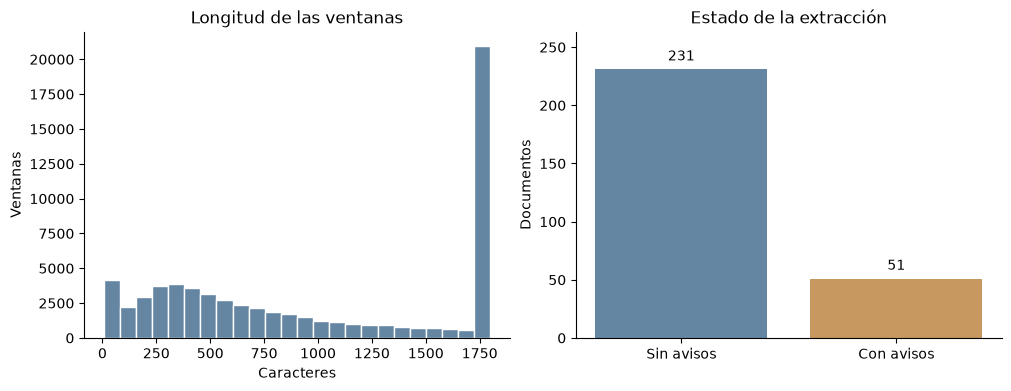

In [17]:
import matplotlib.pyplot as plt

n_pdf = sum(any(e["paginas_pdf"] is not None for e in r["extraccion"]) for r in registros)
n_paginas = sum(e["paginas_pdf"] or 0 for r in registros for e in r["extraccion"])
n_extraccion_revisar = sum(r["estado_extraccion"] == "revisar" for r in registros)
n_ambiguas = sum(u["tipo_unidad"] == "encabezado_ambiguo" for u in unidades)
n_eof = sum(any(e.get("cierre_pdf_completo") is False for e in r["extraccion"]) for r in registros)
n_anotados = sum(r.get("edicion_con_anotaciones", False) for r in registros)

display(pd.Series({
    "Documentos extraídos": len(textos),
    "Documentos PDF": n_pdf,
    "Páginas PDF": n_paginas,
    "Unidades completas": len(unidades),
    "Ventanas": len(fragmentos),
    "Comprobaciones correctas": resumen["comprobaciones_correctas"],
    "Documentos con avisos": n_extraccion_revisar,
    "Encabezados ambiguos": n_ambiguas,
    "PDF sin cierre completo": n_eof,
    "Documentos con notas editoriales": n_anotados,
}, name="Total").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
axes[0].hist(tabla_fragmentos["caracteres"], bins=24, color="#6486a3", edgecolor="white")
axes[0].set_title("Longitud de las ventanas")
axes[0].set_xlabel("Caracteres")
axes[0].set_ylabel("Ventanas")

estados = pd.Series(Counter(r["estado_extraccion"] for r in registros))
estados.index = estados.index.map({"extraido": "Sin avisos", "revisar": "Con avisos", "error": "Error"})
barras = axes[1].bar(estados.index, estados.values, color=["#6486a3", "#c79860", "#a95b55"][:len(estados)])
axes[1].bar_label(barras, padding=4)
axes[1].set_title("Estado de la extracción")
axes[1].set_ylabel("Documentos")
axes[1].set_ylim(0, estados.max() * 1.14)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Resultados

Se procesaron 282 documentos y 1304 páginas PDF. Se obtuvieron 45242 unidades completas y 65649 ventanas de hasta 1800 caracteres.

Pasaron las 20 comprobaciones de integridad, cobertura y procedencia.

Quedaron 51 documentos con avisos de extracción y 4904 encabezados ambiguos. Además, 14 PDF tienen el cierre incompleto y 10 documentos contienen notas editoriales.

## Decisiones

- Usar las ventanas para buscar y recuperar la unidad completa como evidencia.
- Dejar el artículo nulo en jurisprudencia y cuando su atribución sea ambigua.
- Revisar los registros señalados antes de indexarlos.
- Conservar las marcas de vigencia. La extracción no confirma que una norma siga vigente.
- Repetir la ejecución con el mismo manifiesto y los mismos parámetros.

